# H3 — LDI Post > Mid > Pre

Simple paired t-tests (one-sided):
- Post > Mid
- Mid > Pre
- Post > Pre

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

sns.set(style='whitegrid', context='talk')

df = pd.read_csv(r'/home/achyutananda-sahoo/Desktop/IIITH-BRSM-MST/01_Preprocessing/compiled_preprocessed.csv')
df['boundary_position'] = pd.Categorical(df['boundary_position'], categories=['Pre', 'Mid', 'Post'], ordered=True)

# Ensure participant identity is unique across experiments/conditions
if 'participant_uid' not in df.columns:
    df['participant_uid'] = df['condition'].astype(str) + '_' + df['participant_id'].astype(str)
else:
    df['participant_uid'] = df['participant_uid'].astype(str)

In [2]:
def p_resp(data, trial_type, response, boundary=None):
    x = data[data['trial_type'] == trial_type]
    if boundary is not None:
        x = x[x['boundary_position'] == boundary]
    if x.empty:
        return np.nan
    return (x['user_response'] == response).mean()

lure_boundary_non_null = df.loc[df['trial_type'] == 'Lure', 'boundary_position'].notna().sum()
if lure_boundary_non_null == 0:
    raise ValueError(
        "Cannot compute boundary-specific LDI: all Lure trials have boundary_position = NaN. "
        "Populate boundary_position for Lure trials in preprocessing before running H3."
    )

rows = []
for uid, sub in df.groupby('participant_uid'):
    cond = sub['condition'].iloc[0]
    foil_sim = p_resp(sub, 'Foil', 'Lure')
    rows.append({
        'id': uid,
        'condition': cond,
        'LDI_pre': p_resp(sub, 'Lure', 'Lure', 'Pre') - foil_sim,
        'LDI_mid': p_resp(sub, 'Lure', 'Lure', 'Mid') - foil_sim,
        'LDI_post': p_resp(sub, 'Lure', 'Lure', 'Post') - foil_sim
    })

wide = pd.DataFrame(rows).dropna()
print('Complete participants:', len(wide))
display(wide[['LDI_pre', 'LDI_mid', 'LDI_post']].mean().to_frame('mean').T)

Complete participants: 160


,LDI_pre,LDI_mid,LDI_post
mean,0.326042,0.33197,0.32309


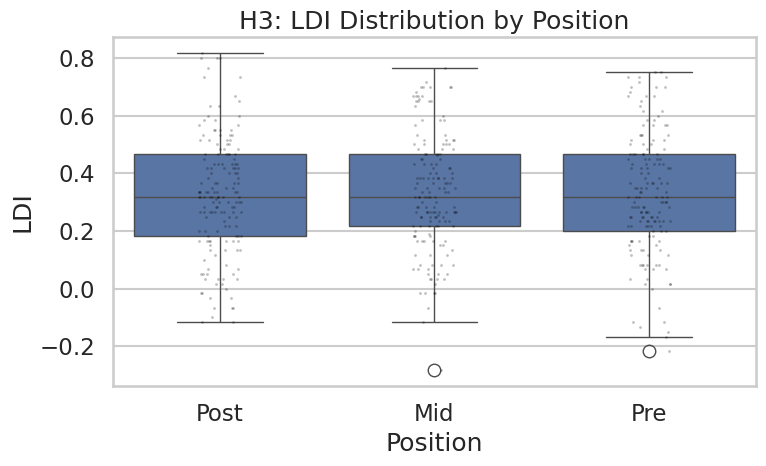

In [3]:
# Visualization: participant-level LDI distributions by position
long = wide.melt(value_vars=['LDI_pre', 'LDI_mid', 'LDI_post'], var_name='position', value_name='LDI')
long['position'] = long['position'].str.replace('LDI_', '').str.capitalize()

plt.figure(figsize=(8, 5))
sns.boxplot(data=long, x='position', y='LDI', order=['Post', 'Mid', 'Pre'])
sns.stripplot(data=long, x='position', y='LDI', order=['Post', 'Mid', 'Pre'], color='black', alpha=0.25, size=2)
plt.title('H3: LDI Distribution by Position')
plt.xlabel('Position')
plt.ylabel('LDI')
plt.tight_layout()
plt.show()

In [4]:
tests = []
for a, b in [('LDI_post', 'LDI_mid'), ('LDI_mid', 'LDI_pre'), ('LDI_post', 'LDI_pre')]:
    test = ttest_rel(wide[a], wide[b], alternative='greater')
    tests.append({
        'comparison': f'{a} > {b}',
        'mean_diff': (wide[a] - wide[b]).mean(),
        't_stat': test.statistic,
        'p_value': test.pvalue,
        'supported (p<.05)': test.pvalue < 0.05
    })

result_df = pd.DataFrame(tests)
display(result_df)

,comparison,mean_diff,t_stat,p_value,supported (p<.05)
0,LDI_post > LDI_mid,-0.008880,-0.703876,0.758730,False
1,LDI_mid > LDI_pre,0.005928,0.518711,0.302342,False
2,LDI_post > LDI_pre,-0.002951,-0.244871,0.596564,False


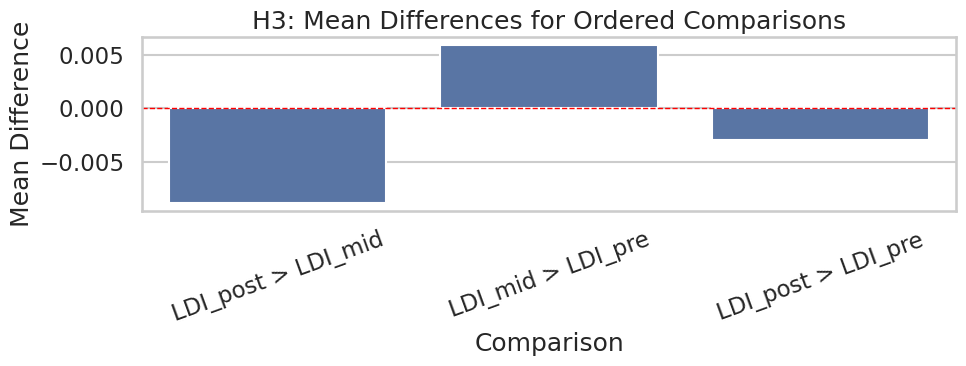

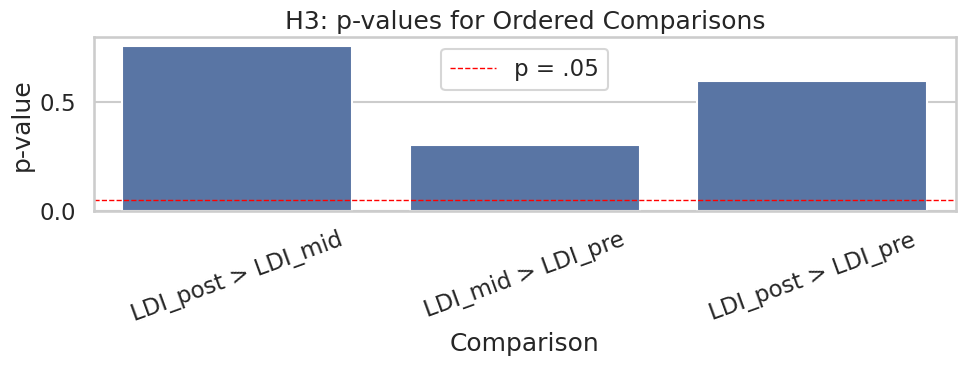

In [5]:
# Visualization: mean differences and p-values from paired tests
plot_df = result_df.copy()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x='comparison', y='mean_diff')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('H3: Mean Differences for Ordered Comparisons')
plt.xlabel('Comparison')
plt.ylabel('Mean Difference')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x='comparison', y='p_value')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p = .05')
plt.title('H3: p-values for Ordered Comparisons')
plt.xlabel('Comparison')
plt.ylabel('p-value')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# REC — Post > Mid > Pre
# REC_position = P(Target→Target at position) - P(Foil→Target)
# Ordered one-sided paired tests: Post > Mid, Mid > Pre, Post > Pre

Complete participants (REC): 160


,REC_pre,REC_mid,REC_post
mean,0.621354,0.625035,0.592485


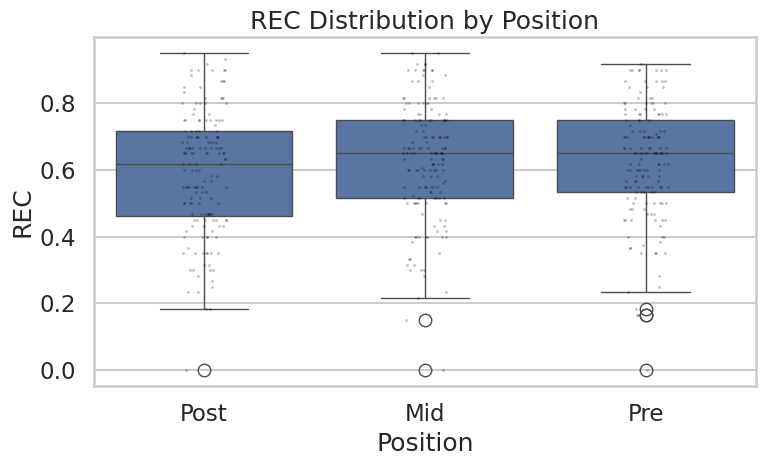

,comparison,mean_diff,t_stat,p_value,supported (p<.05)
0,REC_post > REC_mid,-0.032550,-2.640805,0.995452,False
1,REC_mid > REC_pre,0.003681,0.339817,0.367221,False
2,REC_post > REC_pre,-0.028869,-2.339011,0.989711,False


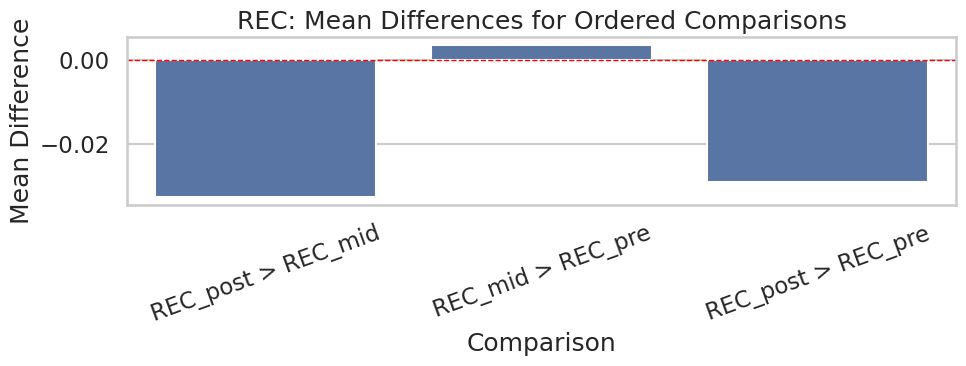

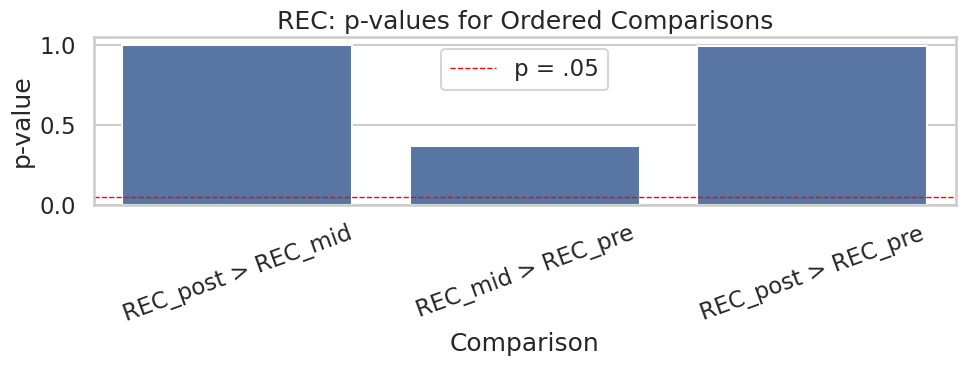

In [7]:
rows_rec = []
for uid, sub in df.groupby('participant_uid'):
    cond = sub['condition'].iloc[0]
    foil_old = p_resp(sub, 'Foil', 'Target')
    rows_rec.append({
        'id': uid,
        'condition': cond,
        'REC_pre': p_resp(sub, 'Target', 'Target', 'Pre') - foil_old,
        'REC_mid': p_resp(sub, 'Target', 'Target', 'Mid') - foil_old,
        'REC_post': p_resp(sub, 'Target', 'Target', 'Post') - foil_old
    })

wide_rec = pd.DataFrame(rows_rec).dropna()
print('Complete participants (REC):', len(wide_rec))
display(wide_rec[['REC_pre', 'REC_mid', 'REC_post']].mean().to_frame('mean').T)

# Visualization: participant-level REC distributions by position
long_rec = wide_rec.melt(value_vars=['REC_pre', 'REC_mid', 'REC_post'], var_name='position', value_name='REC')
long_rec['position'] = long_rec['position'].str.replace('REC_', '').str.capitalize()

plt.figure(figsize=(8, 5))
sns.boxplot(data=long_rec, x='position', y='REC', order=['Post', 'Mid', 'Pre'])
sns.stripplot(data=long_rec, x='position', y='REC', order=['Post', 'Mid', 'Pre'], color='black', alpha=0.25, size=2)
plt.title('REC Distribution by Position')
plt.xlabel('Position')
plt.ylabel('REC')
plt.tight_layout()
plt.show()

# One-sided paired t-tests for ordered REC comparisons
tests_rec = []
for a, b in [('REC_post', 'REC_mid'), ('REC_mid', 'REC_pre'), ('REC_post', 'REC_pre')]:
    test = ttest_rel(wide_rec[a], wide_rec[b], alternative='greater')
    tests_rec.append({
        'comparison': f'{a} > {b}',
        'mean_diff': (wide_rec[a] - wide_rec[b]).mean(),
        't_stat': test.statistic,
        'p_value': test.pvalue,
        'supported (p<.05)': test.pvalue < 0.05
    })

result_rec_df = pd.DataFrame(tests_rec)
display(result_rec_df)

# Visualization: REC mean differences and p-values
plot_rec_df = result_rec_df.copy()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_rec_df, x='comparison', y='mean_diff')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('REC: Mean Differences for Ordered Comparisons')
plt.xlabel('Comparison')
plt.ylabel('Mean Difference')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_rec_df, x='comparison', y='p_value')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p = .05')
plt.title('REC: p-values for Ordered Comparisons')
plt.xlabel('Comparison')
plt.ylabel('p-value')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()